In [303]:
import os
import pprint
import tempfile

from typing import Dict, Text

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

import tensorflow_recommenders as tfrs

In [304]:
ratings = tfds.load("movielens/100k-ratings", split="train")

ratings = ratings.map(lambda x:{
    "movie_title": x["movie_title"],
    "user_id": x["user_id"],
    "user_rating": x["user_rating"]
})

In [305]:
tf.random.set_seed(42)
shuffled = ratings.shuffle(100_000, seed=42, reshuffle_each_iteration=False)
# 데이터셋이니까 셔플할수있는 거임

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

In [306]:
movie_titles = ratings.batch(1_000_000).map(lambda x: x["movie_title"])
user_ids = ratings.batch(1_000_000).map(lambda x: x["user_id"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

In [307]:
# 모델 구현
class RankingModel(tf.keras.Model):
    
    def __init__(self):
        super().__init__()
        embedding_dimension = 32
        
        self.user_embeddings = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_user_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_user_ids)+1, embedding_dimension)
        ])
        self.movie_embeddings = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_movie_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_movie_titles)+1, embedding_dimension)
        ])
        
        self.ratings = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(1)
        ])
        
    def call(self, inputs):
        user_id, movie_title = inputs
        
        user_embedding = self.user_embeddings(user_id)
        movie_embedding = self.movie_embeddings(movie_title)
        
        return self.ratings(tf.concat([user_embedding, movie_embedding], axis=1))

In [308]:
RankingModel()((["42"], ["One Flew Over the Cuckoo's Nest (1975)"]))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.01465774]], dtype=float32)>

In [309]:
task = tfrs.tasks.Ranking(
    loss = tf.keras.losses.MeanSquaredError(),
    metrics = [tf.keras.metrics.RootMeanSquaredError()] # 리스트로 주삼
)
# 임무(task): 네가 오늘 할 일은 평점을 맞히는 것이라고 구체적인 목표와 채점 방식을 통칭해서 task라 부름.
# 1. 모델이 예측값을 내놓음 (Model)
# 2. task에다가 정답과 예측값을 던져주면 알아서 벌점(Loss)를 계산해서 돌려줌.
# 그냥 채점기라고 생각해도 ㄱㅊ

In [310]:
# 전체 모델
class MovielensModel(tfrs.models.Model):
    def __init__(self):
        super().__init__()
        self.ranking_model: tf.keras.Model = RankingModel()
        self.task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
            loss = tf.keras.losses.MeanSquaredError(),
            metrics = [tf.keras.metrics.RootMeanSquaredError()]
        )
    
    def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
        return self.ranking_model((features["user_id"], features["movie_title"]))
    
    def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
        labels = features.pop("user_rating")
        
        rating_predictions = self(features)
        # 지금 모델에 인풋해서 call리턴값을 받아 넣겟다는 뜻.
        
        return self.task(labels=labels, predictions=rating_predictions)
        # 진짜정답, 에측값

In [311]:
model = MovielensModel()
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

In [312]:
cached_train = train.shuffle(100_000).batch(8192).cache()
cached_test = test.batch(4096).cache()
# 에포크가 시작될 때 마다 데이터를 랜덤하게 섞기.

In [313]:
recoding_train = model.fit(cached_train, epochs=3)

Epoch 1/3


2026-03-13 21:02:50.738840: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adagrad/AssignAddVariableOp.


10/10 [==============================] - 2s 47ms/step - root_mean_squared_error: 1.7899 - loss: 2.9891 - regularization_loss: 0.0000e+00 - total_loss: 2.9891
Epoch 2/3
10/10 [==============================] - 0s 11ms/step - root_mean_squared_error: 1.1239 - loss: 1.2660 - regularization_loss: 0.0000e+00 - total_loss: 1.2660
Epoch 3/3
10/10 [==============================] - 0s 10ms/step - root_mean_squared_error: 1.1218 - loss: 1.2613 - regularization_loss: 0.0000e+00 - total_loss: 1.2613


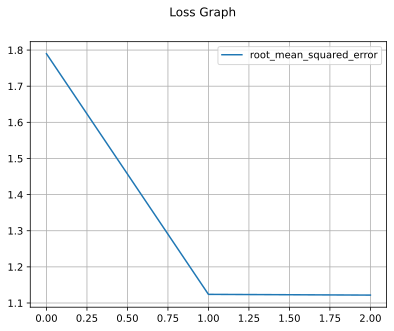

In [314]:
fig, ax = plt.subplots()
fig.suptitle("Loss Graph")
ax.grid()
# ax.plot(recoding_train.history["loss"], label="loss")
ax.plot(recoding_train.history["root_mean_squared_error"], label="root_mean_squared_error")
#ax.plot(recoding_train.history["regularization_loss"], label="regularization_loss")
#ax.plot(recoding_train.history["total_loss"], label="total_loss")
ax.legend()

plt.show()

In [315]:
model.summary()

Model: "movielens_model_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ranking_model_57 (RankingM  multiple                  116641    
 odel)                                                           
                                                                 
 ranking_26 (Ranking)        multiple                  0         
                                                                 
Total params: 116641 (455.63 KB)
Trainable params: 116641 (455.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [316]:
# 마지막 테스트 세트 평가
model.evaluate(cached_test, return_dict=True)
# regularization_loss: 추가 벌점 설정 안 해서 0으로 나온다.
# loss = (root어쩌고)^2

5/5 [==============================] - 1s 16ms/step - root_mean_squared_error: 1.1201 - loss: 1.2497 - regularization_loss: 0.0000e+00 - total_loss: 1.2497


{'root_mean_squared_error': 1.1201447248458862,
 'loss': 1.2277154922485352,
 'regularization_loss': 0.0,
 'total_loss': 1.2277154922485352}

In [317]:
# 순위 모델 테스트
test_ratings = {} # 모델이 예측값 내놓은 거 담아둘 빈 딕셔너리
test_movie_titles = ["M*A*S*H (1970)", "Dances with Wolves (1990)", "Speed (1994)"]
for movie_title in test_movie_titles:
  test_ratings[movie_title] = model({
      "user_id": np.array(["42"]),
      "movie_title": np.array([movie_title])
  })

#  test_ratings["M*A*S*H (1970)"] = 1.42 딕셔너리형태로 저장된다.
#  바구니 상태--> {"M*A*S*H (1970)"": 1.42} (사실1.4라고 깔끔하게 안나옴. tf.Tensor형태임;;)

# print(test_ratings)
print("Ratings:")
for title, score in sorted(test_ratings.items(), key=lambda x: x[1], reverse=True):
  # items()를 호출하면 키값쌍으로 리스트형태로 반환해줌. (안에는 튜플이다.)
  # 다시말해 [ (제목, 점수), (제목,점수)... ] 겉리스트 속튜플 로 만들어줌. items()쓰면!!
  
  # x[0]은 정렬할때 title기준(가나다) 1은 score기준
  # reverse 큰 숫자가 위로 오게 리버스걸어줌.
  # sorted()는 내림/올림차순 정렬을 위한..함수.
  
  print(f"{title}: {score}")

Ratings:
Speed (1994): [[1.561938]]
M*A*S*H (1970): [[1.5507348]]
Dances with Wolves (1990): [[1.5394163]]


In [318]:
tf.saved_model.save(model, "export")

INFO:tensorflow:Assets written to: export/assets


INFO:tensorflow:Assets written to: export/assets


In [324]:
loaded = tf.saved_model.load("export")
loaded({"user_id": np.array(["42"]), "movie_title": np.array(["Speed (1994)"])}).numpy()

array([[3.5877447]], dtype=float32)